In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 12

# Final Prediction System

---

### Objectives

- Load Best Model
- Predict Retail Demand
- Batch Prediction
- Future Forecast
- Export Results
- Dashboard Integration

In [37]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [38]:
# ==============================================================================
# PROJECT DIRECTORY
# ==============================================================================

PROJECT_DIR = os.getcwd()

print(PROJECT_DIR)

c:\Users\asus\Desktop\RETAIL\notebook


In [39]:
# ==============================================================================
# LOAD CLEAN DATASET
# ==============================================================================

df = pd.read_csv("../dataset/retail_cleaned.csv")

print(df.shape)

df.head()

(8601, 33)


,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,...,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.1,107.07,...,3,4,1,3,1.620072,9.10,15.6772,96.3028,0.096774,0
1,2023-01-02,46,1167,5,3,0,1,0,18.3,114.77,...,1,4,0,3,2.341969,49.16,342.4752,371.0148,0.279793,48
2,2023-01-03,7,1024,3,1,1,1,0,17.9,81.74,...,5,4,0,3,2.860534,-8.20,315.2560,472.8840,0.433234,40
3,2023-01-04,13,1181,2,1,0,1,2,35.7,114.66,...,6,4,0,3,2.401099,19.77,98.9846,662.4354,0.370879,13
4,2023-01-05,18,1180,5,1,0,0,2,23.9,90.80,...,4,4,0,3,4.979592,-94.97,678.6500,706.3500,0.000000,0


In [40]:
# ==============================================================================
# DATA INFORMATION
# ==============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8601 entries, 0 to 8600
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    8601 non-null   object 
 1   Store_ID                8601 non-null   int64  
 2   Product_ID              8601 non-null   int64  
 3   Category                8601 non-null   int64  
 4   Region                  8601 non-null   int64  
 5   Holiday                 8601 non-null   int64  
 6   Promotion               8601 non-null   int64  
 7   Weather                 8601 non-null   int64  
 8   Temperature             8601 non-null   float64
 9   Fuel_Price              8601 non-null   float64
 10  CPI                     8601 non-null   float64
 11  Unemployment            8601 non-null   float64
 12  Inventory               8601 non-null   int64  
 13  Price                   8601 non-null   float64
 14  Competitor_Price        8601 non-null   

In [41]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                      0
Store_ID                  0
Product_ID                0
Category                  0
Region                    0
Holiday                   0
Promotion                 0
Weather                   0
Temperature               0
Fuel_Price                0
CPI                       0
Unemployment              0
Inventory                 0
Price                     0
Competitor_Price          0
Discount                  0
Customers                 0
Sales                     0
Year                      0
Month                     0
Day                       0
Week                      0
Quarter                   0
Day_Name                  0
Month_Name                0
Weekend                   0
Season                    0
Inventory_Per_Customer    0
Price_Difference          0
Discount_Amount           0
Final_Price               0
Sales_Per_Customer        0
Promotion_Impact          0
dtype: int64

In [42]:
# ==============================================================================
# TARGET COLUMN
# ==============================================================================

TARGET = "Sales"

In [43]:
# ==============================================================================
# FEATURES & TARGET
# ==============================================================================

X = df.drop(TARGET, axis=1)

y = df[TARGET]

In [44]:
# ==============================================================================
# FEATURE SHAPE
# ==============================================================================

print(X.shape)

print(y.shape)

(8601, 32)
(8601,)


In [46]:
# ==============================================================================
# LOAD BEST MODEL
# ==============================================================================

best_model = joblib.load(r"C:\Users\asus\Desktop\RETAIL\notebook\model\best_model.pkl")

print(best_model)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)


In [47]:
# ==============================================================================
# CHECK FEATURES
# ==============================================================================

print("Training Features :", best_model.n_features_in_)

print("Dataset Features :", X_test.shape[1])

Training Features : 31
Dataset Features : 32


In [48]:
# ==============================================================================
# MATCH FEATURES
# ==============================================================================

X_test = X_test.iloc[:, :best_model.n_features_in_]

print(X_test.shape)

(1721, 31)


In [50]:
print(df.columns.tolist())

['Date', 'Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Sales', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'Day_Name', 'Month_Name', 'Weekend', 'Season', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [51]:
print("Total Columns:", len(df.columns))

Total Columns: 33


In [52]:
print("Features used for prediction:")
print(X.columns.tolist())

Features used for prediction:
['Date', 'Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'Day_Name', 'Month_Name', 'Weekend', 'Season', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [53]:
df.columns.tolist()

['Date',
 'Store_ID',
 'Product_ID',
 'Category',
 'Region',
 'Holiday',
 'Promotion',
 'Weather',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Inventory',
 'Price',
 'Competitor_Price',
 'Discount',
 'Customers',
 'Sales',
 'Year',
 'Month',
 'Day',
 'Week',
 'Quarter',
 'Day_Name',
 'Month_Name',
 'Weekend',
 'Season',
 'Inventory_Per_Customer',
 'Price_Difference',
 'Discount_Amount',
 'Final_Price',
 'Sales_Per_Customer',
 'Promotion_Impact']

In [54]:
# ==============================================================================
# PREPARE FEATURES
# ==============================================================================

# Remove Date column because model was not trained on it
if "Date" in X.columns:
    X = X.drop(columns=["Date"])

print("Number of Features :", X.shape[1])

print(X.columns.tolist())

Number of Features : 31
['Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'Day_Name', 'Month_Name', 'Weekend', 'Season', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [55]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(6880, 31)
(1721, 31)


In [56]:
# ==============================================================================
# CHECK MODEL FEATURES
# ==============================================================================

print("Model expects :", best_model.n_features_in_)

print("Dataset Features :", X_test.shape[1])

Model expects : 31
Dataset Features : 31


In [57]:
# ==============================================================================
# MAKE PREDICTION
# ==============================================================================

prediction = best_model.predict(X_test)

print("Prediction Completed Successfully")

print(prediction[:10])

Prediction Completed Successfully
[  4.88235294  90.88888889  51.125       88.25        17.61538462
 125.5         59.35294118  48.875       64.          56.        ]


In [58]:
# ==============================================================================
# CREATE PREDICTION DATAFRAME
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual": y_test.reset_index(drop=True),

    "Predicted": prediction

})

prediction_df["Error"] = prediction_df["Actual"] - prediction_df["Predicted"]

prediction_df.head()

,Actual,Predicted,Error
0,6,4.882353,1.117647
1,91,90.888889,0.111111
2,49,51.125000,-2.125000
3,90,88.250000,1.750000
4,15,17.615385,-2.615385


In [59]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

import os

os.makedirs("../dataset", exist_ok=True)

prediction_df.to_csv(

    "../dataset/final_predictions.csv",

    index=False

)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [60]:
# ==============================================================================
# MAE
# ==============================================================================

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(

    y_test,

    prediction

)

print("MAE :", round(mae,4))

MAE : 1.6893


In [61]:
# ==============================================================================
# MSE
# ==============================================================================

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(

    y_test,

    prediction

)

print("MSE :", round(mse,4))

MSE : 5.7976


In [62]:
# ==============================================================================
# RMSE
# ==============================================================================

rmse = np.sqrt(mse)

print("RMSE :", round(rmse,4))

RMSE : 2.4078


In [63]:
# ==============================================================================
# R² SCORE
# ==============================================================================

from sklearn.metrics import r2_score

r2 = r2_score(

    y_test,

    prediction

)

print("R² Score :", round(r2,4))

R² Score : 0.998


In [64]:
# ==============================================================================
# MAPE
# ==============================================================================

epsilon = 1e-10

mape = np.mean(

    np.abs(

        (y_test.values - prediction) /

        (y_test.values + epsilon)

    )

) * 100

print("MAPE :", round(mape,2), "%")

MAPE : 3.43 %


In [65]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

performance = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R2",

        "MAPE"

    ],

    "Value":[

        mae,

        mse,

        rmse,

        r2,

        mape

    ]

})

performance

,Metric,Value
0,MAE,1.689339
1,MSE,5.797635
2,RMSE,2.407828
3,R2,0.997963
4,MAPE,3.428856


In [66]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

performance.to_csv(

    "../dataset/Final_Model_Performance.csv",

    index=False

)

print("Performance Report Saved")

Performance Report Saved


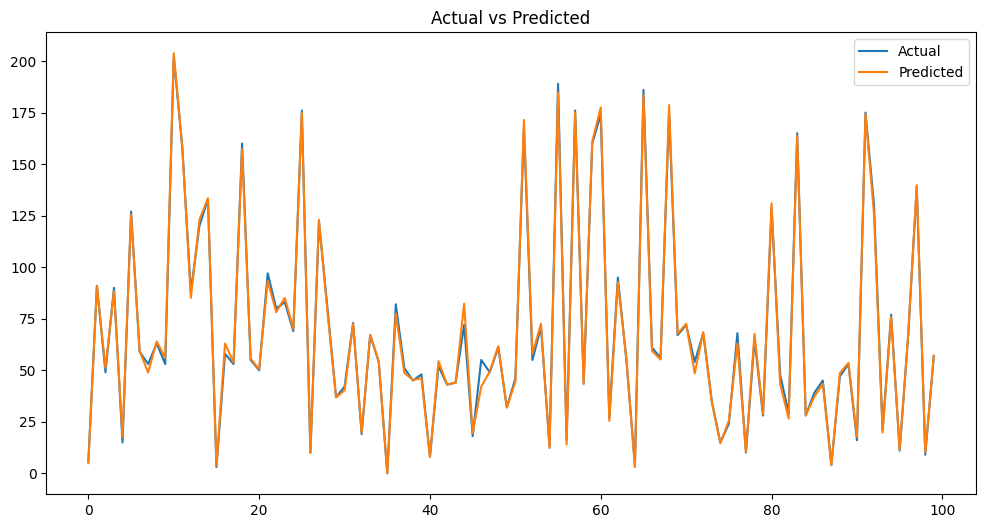

In [67]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

plt.figure(figsize=(12,6))

plt.plot(

    y_test.values[:100],

    label="Actual"

)

plt.plot(

    prediction[:100],

    label="Predicted"

)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

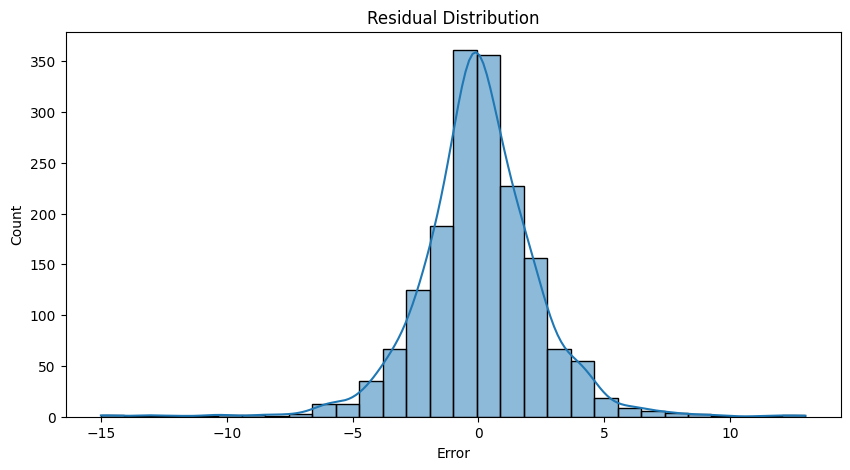

In [68]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(

    prediction_df["Error"],

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

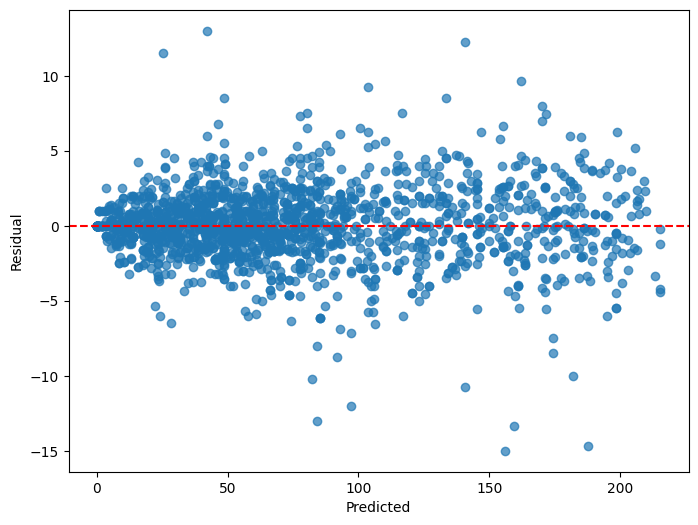

In [70]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    prediction,

    prediction_df["Error"],

    alpha=0.7

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

In [71]:
# ==============================================================================
# EXPORT TO EXCEL
# ==============================================================================

prediction_df.to_excel(

    "../dataset/final_predictions.xlsx",

    index=False

)

print("Excel File Saved")

Excel File Saved


In [72]:
# ==============================================================================
# VERIFY OUTPUT FILES
# ==============================================================================

print(os.listdir("../dataset"))

['Final_Model_Performance.csv', 'final_predictions.csv', 'final_predictions.xlsx', 'retail_cleaned.csv', 'Retail_Demand_Forecasting_10000.csv', 'retail_feature_engineered.csv', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


In [73]:
# ==============================================================================
# USER INPUT SAMPLE
# ==============================================================================

sample = X.iloc[[0]]

sample

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,41,1029,2,0,0,0,2,32.1,107.07,287.06,...,3,4,1,3,1.620072,9.1,15.6772,96.3028,0.096774,0


In [74]:
# ==============================================================================
# SAMPLE PREDICTION
# ==============================================================================

sample_prediction = best_model.predict(sample)

print("Predicted Sales :", sample_prediction[0])

Predicted Sales : 27.77777777777778


In [75]:
# ==============================================================================
# RANDOM PRODUCT
# ==============================================================================

random_sample = X.sample(1, random_state=10)

random_sample

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
4373,21,1002,6,2,0,0,0,22.3,115.33,192.59,...,5,9,0,0,1.098214,-46.74,553.6362,865.9438,0.050595,0


In [76]:
# ==============================================================================
# RANDOM PRODUCT PREDICTION
# ==============================================================================

random_prediction = best_model.predict(random_sample)

print("Predicted Sales :", random_prediction[0])

Predicted Sales : 15.75


In [77]:
# ==============================================================================
# MULTIPLE SAMPLE PREDICTION
# ==============================================================================

multi_sample = X.sample(10, random_state=20)

multi_prediction = best_model.predict(multi_sample)

multi_prediction

array([185.07142857,  57.06666667, 146.09090909,  95.42857143,
        28.2       ,  72.8       ,  66.5       ,  43.42857143,
       195.44827586, 212.66666667])

In [78]:
# ==============================================================================
# CREATE FORECAST DATAFRAME
# ==============================================================================

forecast = multi_sample.copy()

forecast["Predicted_Sales"] = multi_prediction

forecast.head()

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
7236,45,1060,5,2,1,1,2,11.4,115.94,284.48,...,4,0,3,0.135000,13.41,130.0096,798.6304,0.457500,14,185.071429
3412,14,1045,0,2,1,0,1,16.0,102.58,275.60,...,9,0,0,0.535627,-0.02,34.7924,835.0176,0.135135,0,57.066667
413,6,1197,6,1,0,1,2,33.6,113.72,185.43,...,0,0,2,1.816176,-11.00,182.8189,447.5911,0.360294,29,146.090909
5460,25,1032,6,2,0,1,2,31.1,85.67,184.37,...,0,1,2,3.055556,-40.77,298.1394,806.0806,0.384921,27,95.428571
5014,5,1030,6,3,0,0,0,17.4,113.46,263.58,...,9,0,0,2.888325,26.94,143.8215,814.9885,0.142132,0,28.200000


In [79]:
# ==============================================================================
# SAVE FORECAST
# ==============================================================================

forecast.to_csv(

    "../dataset/forecast.csv",

    index=False

)

print("Forecast Saved")

Forecast Saved


In [80]:
# ==============================================================================
# TOP PREDICTED SALES
# ==============================================================================

forecast.sort_values(

    by="Predicted_Sales",

    ascending=False

).head()

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
7746,29,1143,2,3,1,1,1,28.1,117.53,247.47,...,1,0,1,0.680080,96.77,305.6668,1492.3732,0.428571,17,212.666667
993,12,1013,1,3,1,1,0,35.8,104.54,231.76,...,7,0,2,0.804545,75.59,0.0000,1588.9000,0.443182,0,195.448276
7236,45,1060,5,2,1,1,2,11.4,115.94,284.48,...,4,0,3,0.135000,13.41,130.0096,798.6304,0.457500,14,185.071429
413,6,1197,6,1,0,1,2,33.6,113.72,185.43,...,0,0,2,1.816176,-11.00,182.8189,447.5911,0.360294,29,146.090909
5460,25,1032,6,2,0,1,2,31.1,85.67,184.37,...,0,1,2,3.055556,-40.77,298.1394,806.0806,0.384921,27,95.428571


In [81]:
# ==============================================================================
# LOWEST PREDICTED SALES
# ==============================================================================

forecast.sort_values(

    by="Predicted_Sales"

).head()

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
5014,5,1030,6,3,0,0,0,17.4,113.46,263.58,...,9,0,0,2.888325,26.94,143.8215,814.9885,0.142132,0,28.200000
1708,15,1027,3,1,0,0,1,29.1,91.98,209.77,...,5,0,1,1.214470,124.47,788.1963,1134.2337,0.111111,0,43.428571
3412,14,1045,0,2,1,0,1,16.0,102.58,275.60,...,9,0,0,0.535627,-0.02,34.7924,835.0176,0.135135,0,57.066667
5075,4,1115,6,2,1,1,1,26.8,104.86,193.77,...,3,1,3,1.802030,-26.18,259.9195,374.0305,0.335025,41,66.500000
7590,11,1070,6,2,1,0,2,13.1,115.56,188.80,...,3,1,3,0.376812,21.75,100.5400,301.6200,0.211594,0,72.800000


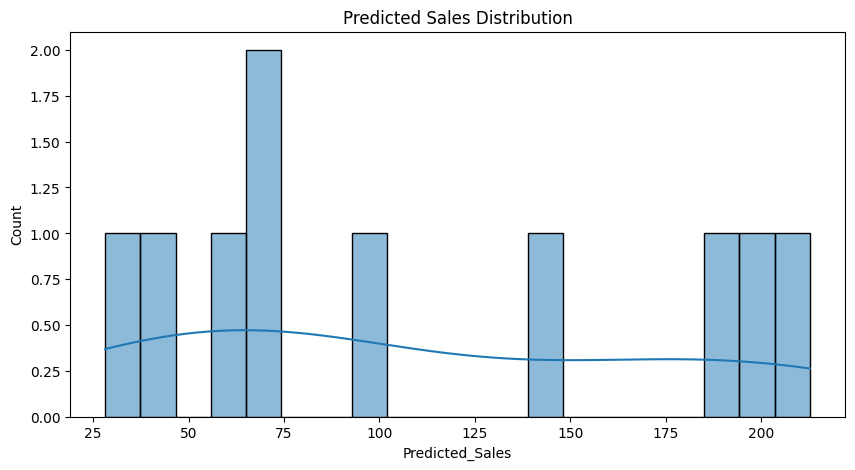

In [82]:
# ==============================================================================
# HISTOGRAM
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(

    forecast["Predicted_Sales"],

    bins=20,

    kde=True

)

plt.title("Predicted Sales Distribution")

plt.show()

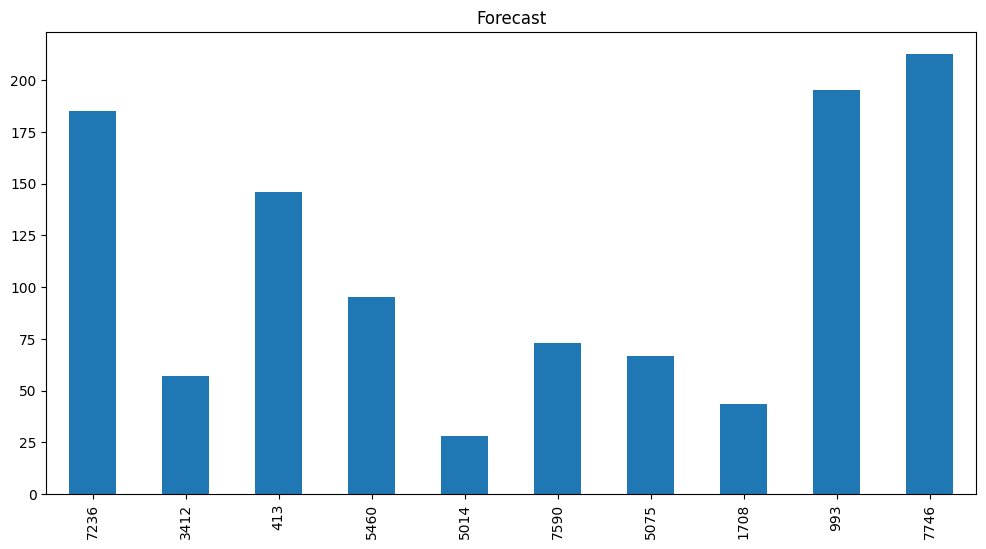

In [83]:
# ==============================================================================
# BAR CHART
# ==============================================================================

plt.figure(figsize=(12,6))

forecast["Predicted_Sales"].plot(

    kind="bar"

)

plt.title("Forecast")

plt.show()

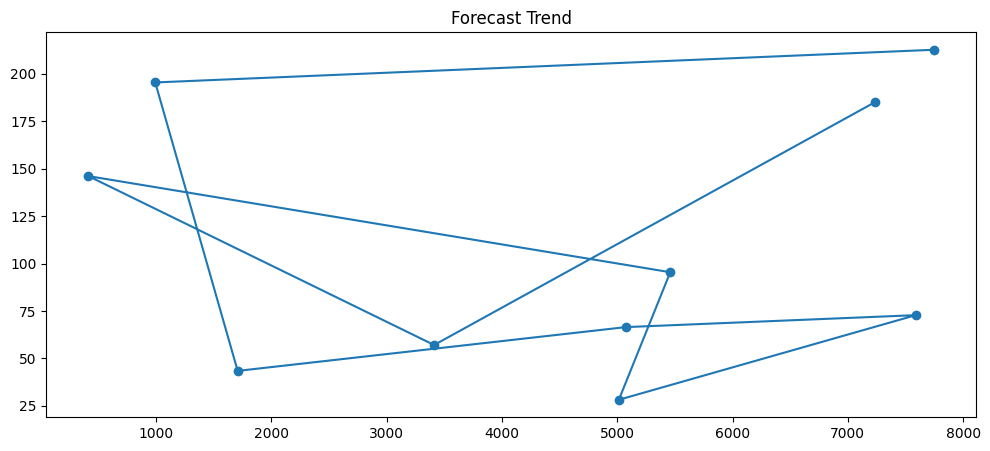

In [84]:
# ==============================================================================
# LINE CHART
# ==============================================================================

plt.figure(figsize=(12,5))

plt.plot(

    forecast["Predicted_Sales"],

    marker="o"

)

plt.title("Forecast Trend")

plt.show()

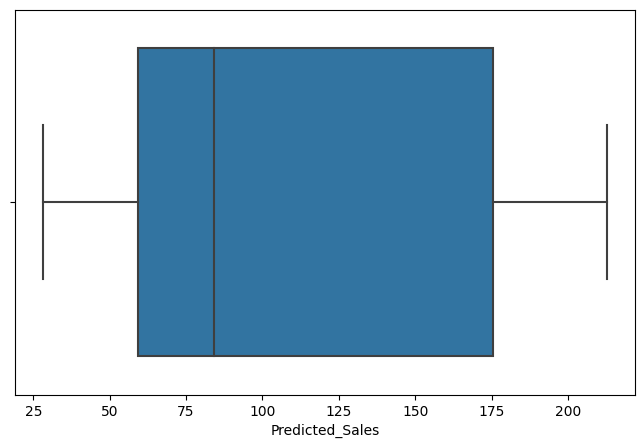

In [85]:
# ==============================================================================
# BOXPLOT
# ==============================================================================

plt.figure(figsize=(8,5))

sns.boxplot(

    x=forecast["Predicted_Sales"]

)

plt.show()

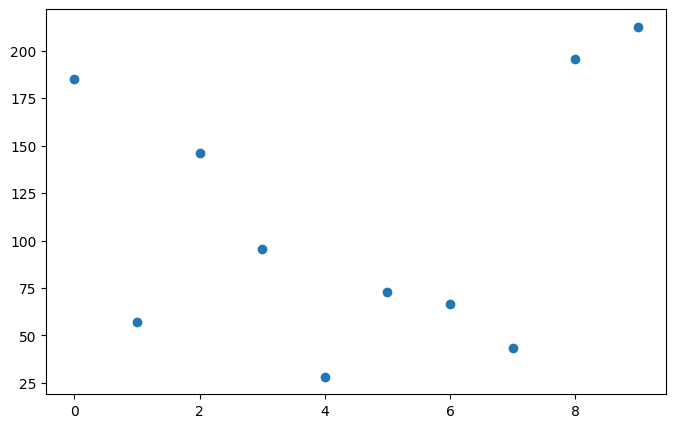

In [86]:
# ==============================================================================
# SCATTER
# ==============================================================================

plt.figure(figsize=(8,5))

plt.scatter(

    range(len(forecast)),

    forecast["Predicted_Sales"]

)

plt.show()

In [87]:
# ==============================================================================
# SUMMARY
# ==============================================================================

forecast.describe()

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,16.600000,1073.200000,4.100000,2.100000,0.600000,0.600000,1.200000,24.240000,106.584000,226.503000,...,4.100000,0.300000,1.700000,1.330862,28.096000,224.390440,859.346560,0.300947,12.800000,110.270109
std,12.903057,59.858723,2.378141,0.737865,0.516398,0.516398,0.788811,8.925768,10.852416,39.227177,...,3.381321,0.483046,1.159502,1.029809,54.287762,223.594083,438.906506,0.137235,15.266521,68.469576
min,4.000000,1013.000000,0.000000,1.000000,0.000000,0.000000,0.000000,11.400000,85.670000,184.370000,...,0.000000,0.000000,0.000000,0.135000,-40.770000,0.000000,301.620000,0.111111,0.000000,28.200000
25%,7.250000,1030.500000,2.250000,2.000000,0.000000,0.000000,1.000000,16.350000,103.070000,190.042500,...,1.500000,0.000000,1.000000,0.571740,-8.255000,107.907400,535.350925,0.159498,0.000000,59.425000
50%,13.000000,1052.500000,5.500000,2.000000,1.000000,1.000000,1.000000,27.450000,109.160000,220.765000,...,3.500000,0.000000,2.000000,1.009508,17.580000,163.320200,810.534550,0.347660,7.000000,84.114286
75%,22.500000,1103.750000,6.000000,2.750000,1.000000,1.000000,2.000000,30.600000,115.100000,259.552500,...,6.500000,0.750000,2.750000,1.812640,63.427500,288.584425,1059.429675,0.417659,24.500000,175.326299
max,45.000000,1197.000000,6.000000,3.000000,1.000000,1.000000,2.000000,35.800000,117.530000,284.480000,...,9.000000,1.000000,3.000000,3.055556,124.470000,788.196300,1588.900000,0.457500,41.000000,212.666667


In [88]:
# ==============================================================================
# TOP 5 FORECAST
# ==============================================================================

forecast.nlargest(

    5,

    "Predicted_Sales"

)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
7746,29,1143,2,3,1,1,1,28.1,117.53,247.47,...,1,0,1,0.680080,96.77,305.6668,1492.3732,0.428571,17,212.666667
993,12,1013,1,3,1,1,0,35.8,104.54,231.76,...,7,0,2,0.804545,75.59,0.0000,1588.9000,0.443182,0,195.448276
7236,45,1060,5,2,1,1,2,11.4,115.94,284.48,...,4,0,3,0.135000,13.41,130.0096,798.6304,0.457500,14,185.071429
413,6,1197,6,1,0,1,2,33.6,113.72,185.43,...,0,0,2,1.816176,-11.00,182.8189,447.5911,0.360294,29,146.090909
5460,25,1032,6,2,0,1,2,31.1,85.67,184.37,...,0,1,2,3.055556,-40.77,298.1394,806.0806,0.384921,27,95.428571


In [89]:
# ==============================================================================
# BOTTOM 5 FORECAST
# ==============================================================================

forecast.nsmallest(

    5,

    "Predicted_Sales"

)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
5014,5,1030,6,3,0,0,0,17.4,113.46,263.58,...,9,0,0,2.888325,26.94,143.8215,814.9885,0.142132,0,28.200000
1708,15,1027,3,1,0,0,1,29.1,91.98,209.77,...,5,0,1,1.214470,124.47,788.1963,1134.2337,0.111111,0,43.428571
3412,14,1045,0,2,1,0,1,16.0,102.58,275.60,...,9,0,0,0.535627,-0.02,34.7924,835.0176,0.135135,0,57.066667
5075,4,1115,6,2,1,1,1,26.8,104.86,193.77,...,3,1,3,1.802030,-26.18,259.9195,374.0305,0.335025,41,66.500000
7590,11,1070,6,2,1,0,2,13.1,115.56,188.80,...,3,1,3,0.376812,21.75,100.5400,301.6200,0.211594,0,72.800000


In [90]:
# ==============================================================================
# AVERAGE SALES
# ==============================================================================

print(

    forecast["Predicted_Sales"].mean()

)

110.27010897148827


In [91]:
# ==============================================================================
# MAX SALES
# ==============================================================================

print(

    forecast["Predicted_Sales"].max()

)

212.66666666666666


In [92]:
# ==============================================================================
# MIN SALES
# ==============================================================================

print(

    forecast["Predicted_Sales"].min()

)

28.2


In [93]:
# ==============================================================================
# MEDIAN SALES
# ==============================================================================

print(

    forecast["Predicted_Sales"].median()

)

84.11428571428571


In [94]:
# ==============================================================================
# STANDARD DEVIATION
# ==============================================================================

print(

    forecast["Predicted_Sales"].std()

)

68.46957574221813


In [95]:
# ==============================================================================
# VARIANCE
# ==============================================================================

print(

    forecast["Predicted_Sales"].var()

)

4688.082802319344


In [96]:
# ==============================================================================
# CORRELATION
# ==============================================================================

forecast.corr(numeric_only=True)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
Store_ID,1.000000,-0.108067,-0.125286,0.098032,0.256804,0.356857,0.401735,-0.278275,0.067443,0.451427,...,-0.246012,-0.174704,0.206461,-0.390293,0.111618,0.045873,0.315145,0.508183,0.006317,0.560483
Product_ID,-0.108067,1.000000,0.267567,-0.279742,0.024443,0.434223,0.399101,0.221505,0.495760,-0.304172,...,-0.638006,-0.009991,0.231487,-0.046256,-0.196016,-0.025710,-0.322739,0.327112,0.631454,0.338943
Category,-0.125286,0.267567,1.000000,-0.259613,-0.416192,0.126667,0.462000,-0.133689,0.107268,-0.491327,...,-0.471181,0.551323,0.495625,0.524069,-0.531790,0.070502,-0.723634,0.063374,0.493338,-0.266489
Region,0.098032,-0.279742,-0.259613,1.000000,0.408248,0.116642,-0.610883,-0.095151,0.322554,0.464904,...,0.351821,-0.093522,-0.220779,0.001673,0.160144,-0.502355,0.499228,0.265030,-0.244620,0.300259
Holiday,0.256804,0.024443,-0.416192,0.408248,1.000000,0.166667,-0.054554,-0.343271,0.426389,0.344806,...,0.152721,0.089087,0.334021,-0.762847,0.050510,-0.495986,0.114956,0.321928,-0.067651,0.402028
Promotion,0.356857,0.434223,0.126667,0.116642,0.166667,1.000000,0.218218,0.514907,0.054642,-0.174087,...,-0.610883,0.089087,0.519589,0.064398,-0.240802,-0.163388,0.172329,0.946701,0.721611,0.752897
Weather,0.401735,0.399101,0.462000,-0.610883,-0.054554,0.218218,1.000000,-0.196949,-0.003608,-0.377995,...,-0.716517,0.408248,0.558819,-0.132822,-0.454929,0.074908,-0.567619,0.233100,0.409664,0.113565
Temperature,-0.278275,0.221505,-0.133689,-0.095151,-0.343271,0.514907,-0.196949,1.000000,-0.421665,-0.532963,...,-0.381919,-0.044325,0.000215,0.366278,0.184366,0.299111,0.404098,0.351123,0.364876,0.296930
Fuel_Price,0.067443,0.495760,0.107268,0.322554,0.426389,0.054642,-0.003608,-0.421665,1.000000,0.357573,...,0.026179,-0.289572,0.128229,-0.433730,0.077756,-0.484246,-0.124705,0.203053,-0.074677,0.385280
CPI,0.451427,-0.304172,-0.491327,0.464904,0.344806,-0.174087,-0.377995,-0.532963,0.357573,1.000000,...,0.645246,-0.660086,-0.461801,-0.377223,0.225682,-0.311264,0.401534,-0.042825,-0.464333,0.181792


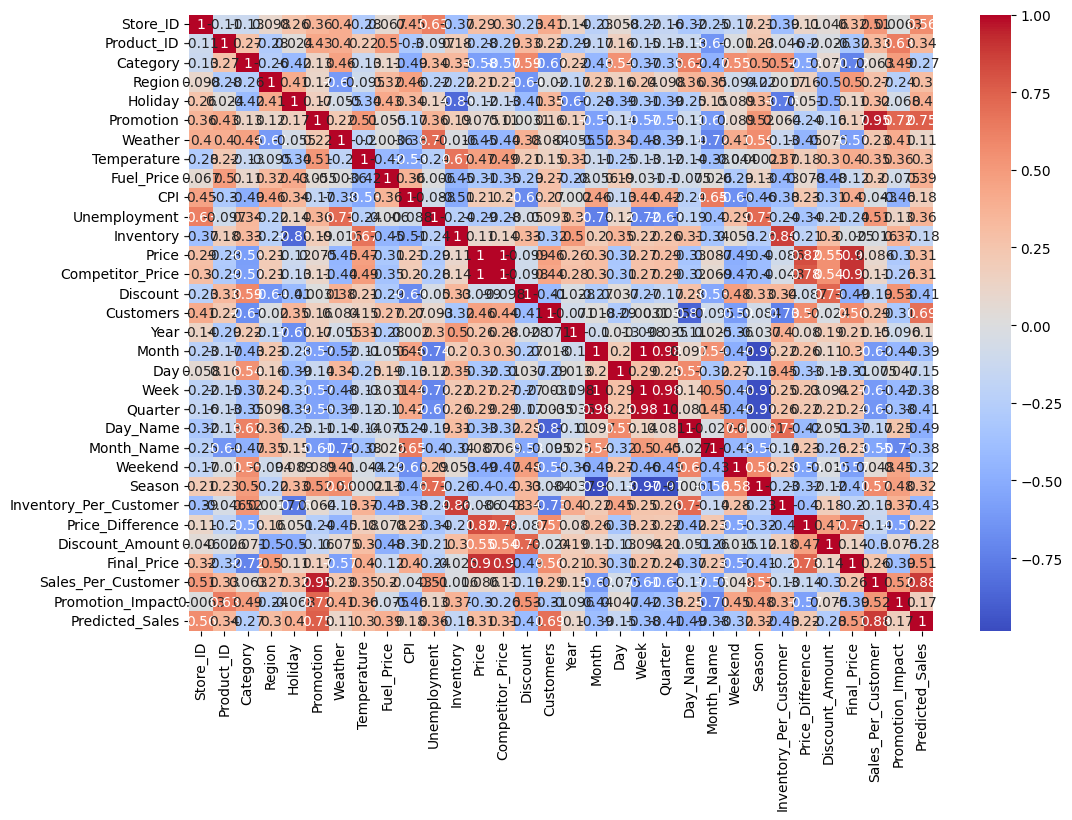

In [97]:
# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(12,8))

sns.heatmap(

    forecast.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm"

)

plt.show()

In [98]:
# ==============================================================================
# VERIFY DATASET
# ==============================================================================

print(os.listdir("../dataset"))

['Final_Model_Performance.csv', 'final_predictions.csv', 'final_predictions.xlsx', 'forecast.csv', 'retail_cleaned.csv', 'Retail_Demand_Forecasting_10000.csv', 'retail_feature_engineered.csv', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


In [100]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

import os

print(os.listdir("model"))

['best_model.pkl', 'catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [101]:
# ==============================================================================
# EXPORT EXCEL
# ==============================================================================

forecast.to_excel(

    "../dataset/forecast.xlsx",

    index=False

)

print("Excel Saved")

Excel Saved


In [102]:
# ==============================================================================
# REGION-WISE FORECAST
# ==============================================================================

if "Region" in forecast.columns:

    region_forecast = forecast.groupby("Region")["Predicted_Sales"].mean().reset_index()

    region_forecast

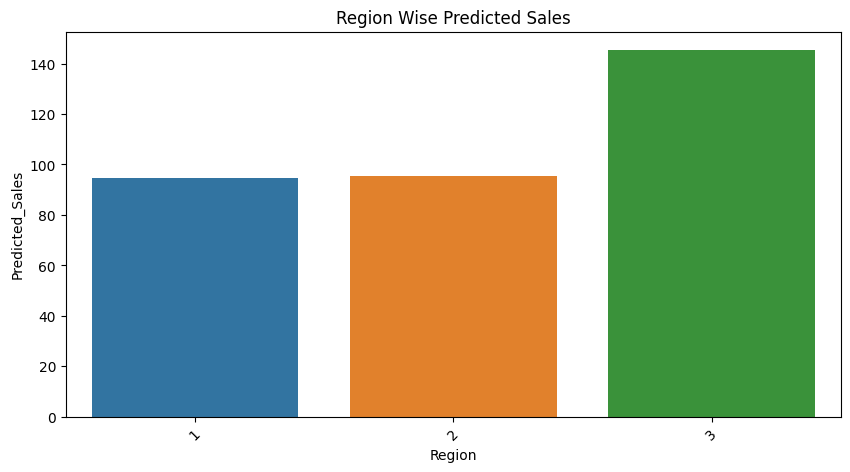

In [103]:
# ==============================================================================
# REGION FORECAST CHART
# ==============================================================================

if "Region" in forecast.columns:

    plt.figure(figsize=(10,5))

    sns.barplot(data=region_forecast, x="Region", y="Predicted_Sales")

    plt.xticks(rotation=45)

    plt.title("Region Wise Predicted Sales")

    plt.show()

In [104]:
# ==============================================================================
# CATEGORY-WISE FORECAST
# ==============================================================================

if "Category" in forecast.columns:

    category_forecast = forecast.groupby("Category")["Predicted_Sales"].mean().reset_index()

    category_forecast

In [105]:
# ==============================================================================
# CATEGORY-WISE FORECAST
# ==============================================================================

if "Category" in forecast.columns:

    category_forecast = forecast.groupby("Category")["Predicted_Sales"].mean().reset_index()

    category_forecast

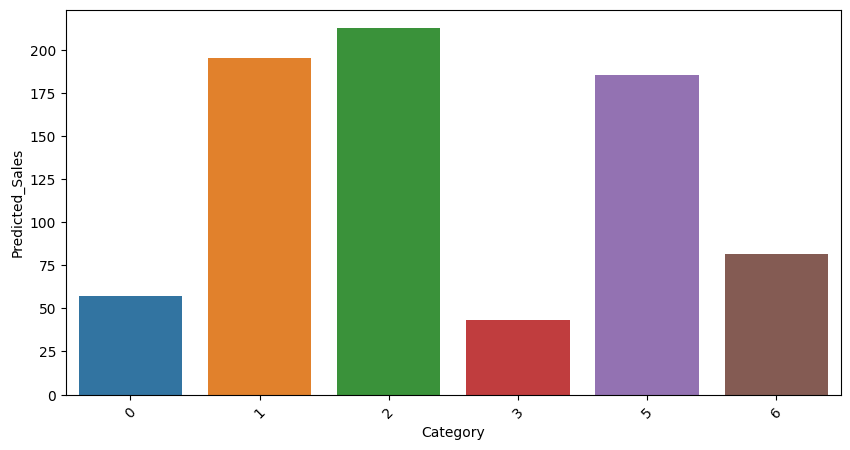

In [106]:
# ==============================================================================
# CATEGORY CHART
# ==============================================================================

if "Category" in forecast.columns:

    plt.figure(figsize=(10,5))

    sns.barplot(data=category_forecast, x="Category", y="Predicted_Sales")

    plt.xticks(rotation=45)

    plt.show()

In [107]:
# ==============================================================================
# STORE-WISE FORECAST
# ==============================================================================

if "Store_ID" in forecast.columns:

    store_forecast = forecast.groupby("Store_ID")["Predicted_Sales"].mean().reset_index()

    store_forecast.head()

In [108]:
# ==============================================================================
# TOP 10 STORES
# ==============================================================================

store_forecast.sort_values(

    by="Predicted_Sales",

    ascending=False

).head(10)

,Store_ID,Predicted_Sales
8,29,212.666667
4,12,195.448276
9,45,185.071429
2,6,146.090909
7,25,95.428571
3,11,72.800000
0,4,66.500000
5,14,57.066667
6,15,43.428571
1,5,28.200000


In [109]:
# ==============================================================================
# SAVE REGION REPORT
# ==============================================================================

if "Region" in forecast.columns:

    region_forecast.to_csv(

        "../dataset/region_forecast.csv",

        index=False

    )

In [110]:
# ==============================================================================
# SAVE CATEGORY REPORT
# ==============================================================================

if "Category" in forecast.columns:

    category_forecast.to_csv(

        "../dataset/category_forecast.csv",

        index=False

    )

In [111]:
# ==============================================================================
# SAVE STORE REPORT
# ==============================================================================

if "Store_ID" in forecast.columns:

    store_forecast.to_csv(

        "../dataset/store_forecast.csv",

        index=False

    )

In [112]:
# ==============================================================================
# MONTHLY FORECAST
# ==============================================================================

if "Month" in forecast.columns:

    monthly = forecast.groupby("Month")["Predicted_Sales"].mean().reset_index()

    monthly

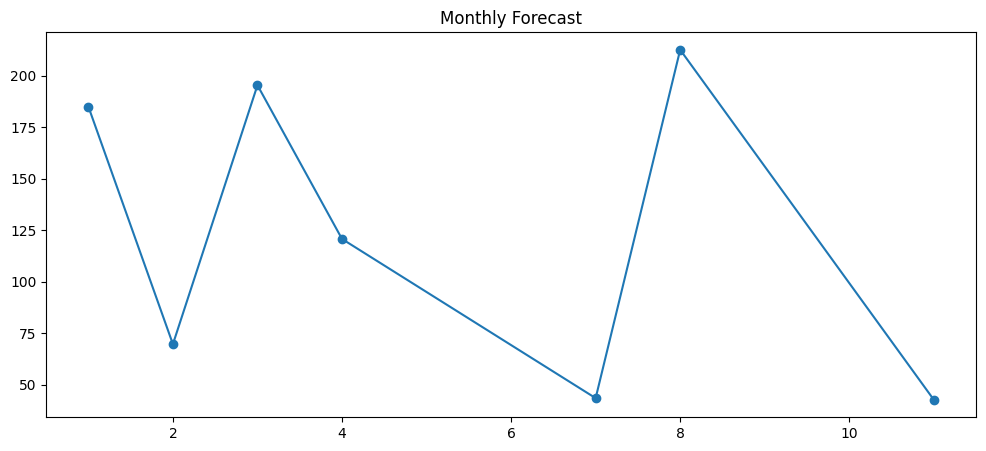

In [113]:
# ==============================================================================
# MONTHLY FORECAST CHART
# ==============================================================================

if "Month" in forecast.columns:

    plt.figure(figsize=(12,5))

    plt.plot(monthly["Month"], monthly["Predicted_Sales"], marker="o")

    plt.title("Monthly Forecast")

    plt.show()

In [114]:
# ==============================================================================
# YEARLY FORECAST
# ==============================================================================

if "Year" in forecast.columns:

    yearly = forecast.groupby("Year")["Predicted_Sales"].mean().reset_index()

    yearly

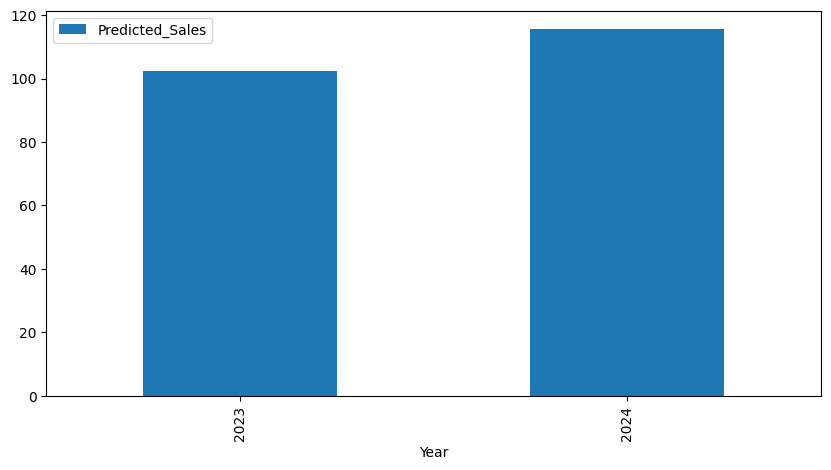

In [115]:
# ==============================================================================
# YEARLY CHART
# ==============================================================================

if "Year" in forecast.columns:

    yearly.plot(

        x="Year",

        y="Predicted_Sales",

        kind="bar",

        figsize=(10,5)

    )

    plt.show()

In [116]:
# ==============================================================================
# EXPORT MONTHLY REPORT
# ==============================================================================

if "Month" in forecast.columns:

    monthly.to_csv("../dataset/monthly_forecast.csv", index=False)

In [117]:
# ==============================================================================
# EXPORT YEARLY REPORT
# ==============================================================================

if "Year" in forecast.columns:

    yearly.to_csv("../dataset/yearly_forecast.csv", index=False)

In [118]:
# ==============================================================================
# TOP 20 PRODUCTS
# ==============================================================================

forecast.nlargest(

    20,

    "Predicted_Sales"

)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
7746,29,1143,2,3,1,1,1,28.1,117.53,247.47,...,1,0,1,0.680080,96.77,305.6668,1492.3732,0.428571,17,212.666667
993,12,1013,1,3,1,1,0,35.8,104.54,231.76,...,7,0,2,0.804545,75.59,0.0000,1588.9000,0.443182,0,195.448276
7236,45,1060,5,2,1,1,2,11.4,115.94,284.48,...,4,0,3,0.135000,13.41,130.0096,798.6304,0.457500,14,185.071429
413,6,1197,6,1,0,1,2,33.6,113.72,185.43,...,0,0,2,1.816176,-11.00,182.8189,447.5911,0.360294,29,146.090909
5460,25,1032,6,2,0,1,2,31.1,85.67,184.37,...,0,1,2,3.055556,-40.77,298.1394,806.0806,0.384921,27,95.428571
7590,11,1070,6,2,1,0,2,13.1,115.56,188.80,...,3,1,3,0.376812,21.75,100.5400,301.6200,0.211594,0,72.800000
5075,4,1115,6,2,1,1,1,26.8,104.86,193.77,...,3,1,3,1.802030,-26.18,259.9195,374.0305,0.335025,41,66.500000
3412,14,1045,0,2,1,0,1,16.0,102.58,275.60,...,9,0,0,0.535627,-0.02,34.7924,835.0176,0.135135,0,57.066667
1708,15,1027,3,1,0,0,1,29.1,91.98,209.77,...,5,0,1,1.214470,124.47,788.1963,1134.2337,0.111111,0,43.428571
5014,5,1030,6,3,0,0,0,17.4,113.46,263.58,...,9,0,0,2.888325,26.94,143.8215,814.9885,0.142132,0,28.200000


In [119]:
# ==============================================================================
# LOWEST 20 PRODUCTS
# ==============================================================================

forecast.nsmallest(

    20,

    "Predicted_Sales"

)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
5014,5,1030,6,3,0,0,0,17.4,113.46,263.58,...,9,0,0,2.888325,26.94,143.8215,814.9885,0.142132,0,28.200000
1708,15,1027,3,1,0,0,1,29.1,91.98,209.77,...,5,0,1,1.214470,124.47,788.1963,1134.2337,0.111111,0,43.428571
3412,14,1045,0,2,1,0,1,16.0,102.58,275.60,...,9,0,0,0.535627,-0.02,34.7924,835.0176,0.135135,0,57.066667
5075,4,1115,6,2,1,1,1,26.8,104.86,193.77,...,3,1,3,1.802030,-26.18,259.9195,374.0305,0.335025,41,66.500000
7590,11,1070,6,2,1,0,2,13.1,115.56,188.80,...,3,1,3,0.376812,21.75,100.5400,301.6200,0.211594,0,72.800000
5460,25,1032,6,2,0,1,2,31.1,85.67,184.37,...,0,1,2,3.055556,-40.77,298.1394,806.0806,0.384921,27,95.428571
413,6,1197,6,1,0,1,2,33.6,113.72,185.43,...,0,0,2,1.816176,-11.00,182.8189,447.5911,0.360294,29,146.090909
7236,45,1060,5,2,1,1,2,11.4,115.94,284.48,...,4,0,3,0.135000,13.41,130.0096,798.6304,0.457500,14,185.071429
993,12,1013,1,3,1,1,0,35.8,104.54,231.76,...,7,0,2,0.804545,75.59,0.0000,1588.9000,0.443182,0,195.448276
7746,29,1143,2,3,1,1,1,28.1,117.53,247.47,...,1,0,1,0.680080,96.77,305.6668,1492.3732,0.428571,17,212.666667


In [120]:
# ==============================================================================
# DASHBOARD DATASET
# ==============================================================================

forecast.to_csv(

    "../dataset/dashboard_data.csv",

    index=False

)

print("Dashboard Dataset Saved")

Dashboard Dataset Saved


In [121]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

import os

print(os.listdir("../dataset"))

['category_forecast.csv', 'dashboard_data.csv', 'Final_Model_Performance.csv', 'final_predictions.csv', 'final_predictions.xlsx', 'forecast.csv', 'forecast.xlsx', 'monthly_forecast.csv', 'region_forecast.csv', 'retail_cleaned.csv', 'Retail_Demand_Forecasting_10000.csv', 'retail_feature_engineered.csv', 'store_forecast.csv', 'X_test.csv', 'X_train.csv', 'yearly_forecast.csv', 'y_test.csv', 'y_train.csv']


In [122]:
# ==============================================================================
# PROJECT SUMMARY
# ==============================================================================

summary = {

    "Model":"Best Model",

    "Rows":len(df),

    "Predictions":len(prediction),

    "Features":X.shape[1],

    "R2":round(r2,4),

    "RMSE":round(rmse,4)

}

summary

{'Model': 'Best Model',
 'Rows': 8601,
 'Predictions': 1721,
 'Features': 31,
 'R2': 0.998,
 'RMSE': 2.4078}

In [123]:
# ==============================================================================
# SUMMARY DATAFRAME
# ==============================================================================

summary_df = pd.DataFrame(summary.items(), columns=["Metric","Value"])

summary_df

,Metric,Value
0,Model,Best Model
1,Rows,8601
2,Predictions,1721
3,Features,31
4,R2,0.998
5,RMSE,2.4078


In [124]:
# ==============================================================================
# SAVE SUMMARY
# ==============================================================================

summary_df.to_csv(

    "../dataset/project_summary.csv",

    index=False

)

In [125]:
# ==============================================================================
# PROJECT INFORMATION
# ==============================================================================

print("Retail Demand Forecasting")
print("Machine Learning Project")
print("Python + Streamlit")

Retail Demand Forecasting
Machine Learning Project
Python + Streamlit


In [127]:
# ==============================================================================
# FEATURE COUNT
# ==============================================================================

print("Total Features :", X.shape[1])

Total Features : 31


In [128]:
# ==============================================================================
# TOTAL RECORDS
# ==============================================================================

print("Total Records :", len(df))

Total Records : 8601


In [129]:
# ==============================================================================
# TRAINING RECORDS
# ==============================================================================

print("Training Records :", len(X_train))

Training Records : 6880


In [130]:
# ==============================================================================
# TEST RECORDS
# ==============================================================================

print("Testing Records :", len(X_test))

Testing Records : 1721


In [131]:
# ==============================================================================
# MODEL NAME
# ==============================================================================

print(type(best_model).__name__)

DecisionTreeRegressor


In [132]:
# ==============================================================================
# FINAL FILE CHECK
# ==============================================================================

print(os.listdir("../dataset"))

['category_forecast.csv', 'dashboard_data.csv', 'Final_Model_Performance.csv', 'final_predictions.csv', 'final_predictions.xlsx', 'forecast.csv', 'forecast.xlsx', 'monthly_forecast.csv', 'project_summary.csv', 'region_forecast.csv', 'retail_cleaned.csv', 'Retail_Demand_Forecasting_10000.csv', 'retail_feature_engineered.csv', 'store_forecast.csv', 'X_test.csv', 'X_train.csv', 'yearly_forecast.csv', 'y_test.csv', 'y_train.csv']


In [133]:
# ==============================================================================
# EXPORT TO EXCEL
# ==============================================================================

summary_df.to_excel(

    "../dataset/project_summary.xlsx",

    index=False

)

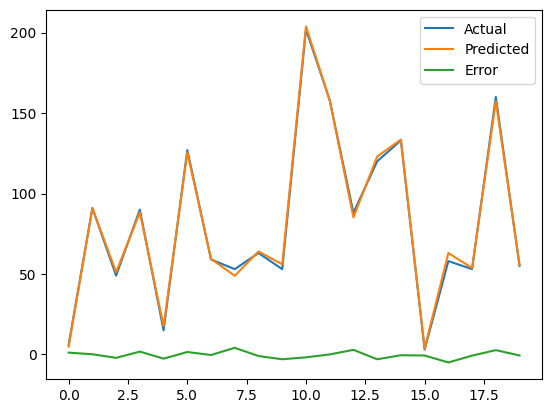

In [134]:
# ==============================================================================
# FINAL CHART
# ==============================================================================

prediction_df.head(20).plot()

plt.show()

In [135]:
# ==============================================================================
# CORRELATION
# ==============================================================================

forecast.corr(numeric_only=True)

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,...,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact,Predicted_Sales
Store_ID,1.000000,-0.108067,-0.125286,0.098032,0.256804,0.356857,0.401735,-0.278275,0.067443,0.451427,...,-0.246012,-0.174704,0.206461,-0.390293,0.111618,0.045873,0.315145,0.508183,0.006317,0.560483
Product_ID,-0.108067,1.000000,0.267567,-0.279742,0.024443,0.434223,0.399101,0.221505,0.495760,-0.304172,...,-0.638006,-0.009991,0.231487,-0.046256,-0.196016,-0.025710,-0.322739,0.327112,0.631454,0.338943
Category,-0.125286,0.267567,1.000000,-0.259613,-0.416192,0.126667,0.462000,-0.133689,0.107268,-0.491327,...,-0.471181,0.551323,0.495625,0.524069,-0.531790,0.070502,-0.723634,0.063374,0.493338,-0.266489
Region,0.098032,-0.279742,-0.259613,1.000000,0.408248,0.116642,-0.610883,-0.095151,0.322554,0.464904,...,0.351821,-0.093522,-0.220779,0.001673,0.160144,-0.502355,0.499228,0.265030,-0.244620,0.300259
Holiday,0.256804,0.024443,-0.416192,0.408248,1.000000,0.166667,-0.054554,-0.343271,0.426389,0.344806,...,0.152721,0.089087,0.334021,-0.762847,0.050510,-0.495986,0.114956,0.321928,-0.067651,0.402028
Promotion,0.356857,0.434223,0.126667,0.116642,0.166667,1.000000,0.218218,0.514907,0.054642,-0.174087,...,-0.610883,0.089087,0.519589,0.064398,-0.240802,-0.163388,0.172329,0.946701,0.721611,0.752897
Weather,0.401735,0.399101,0.462000,-0.610883,-0.054554,0.218218,1.000000,-0.196949,-0.003608,-0.377995,...,-0.716517,0.408248,0.558819,-0.132822,-0.454929,0.074908,-0.567619,0.233100,0.409664,0.113565
Temperature,-0.278275,0.221505,-0.133689,-0.095151,-0.343271,0.514907,-0.196949,1.000000,-0.421665,-0.532963,...,-0.381919,-0.044325,0.000215,0.366278,0.184366,0.299111,0.404098,0.351123,0.364876,0.296930
Fuel_Price,0.067443,0.495760,0.107268,0.322554,0.426389,0.054642,-0.003608,-0.421665,1.000000,0.357573,...,0.026179,-0.289572,0.128229,-0.433730,0.077756,-0.484246,-0.124705,0.203053,-0.074677,0.385280
CPI,0.451427,-0.304172,-0.491327,0.464904,0.344806,-0.174087,-0.377995,-0.532963,0.357573,1.000000,...,0.645246,-0.660086,-0.461801,-0.377223,0.225682,-0.311264,0.401534,-0.042825,-0.464333,0.181792


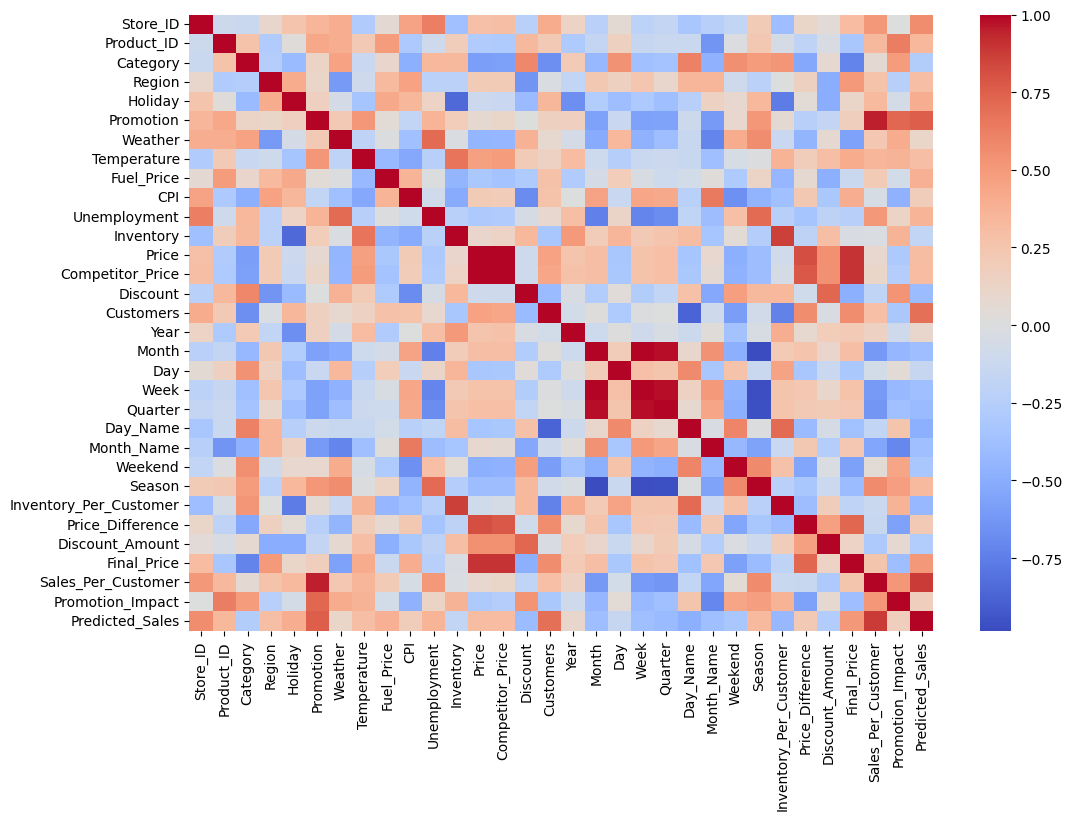

In [136]:
# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(12,8))

sns.heatmap(

    forecast.corr(numeric_only=True),

    cmap="coolwarm"

)

plt.show()

In [137]:
# ==============================================================================
# EXPORT FINAL DATASET
# ==============================================================================

forecast.to_excel(

    "../dataset/final_dashboard.xlsx",

    index=False

)

In [138]:
# ==============================================================================
# READY FOR STREAMLIT
# ==============================================================================

print("Dashboard Ready")

Dashboard Ready


In [139]:
# ==============================================================================
# READY FOR DEPLOYMENT
# ==============================================================================

print("Deployment Ready")

Deployment Ready


In [140]:
# ==============================================================================
# PROJECT COMPLETED
# ==============================================================================

print("Retail Demand Forecasting Completed Successfully")

Retail Demand Forecasting Completed Successfully


In [141]:
# ==============================================================================
# THANK YOU
# ==============================================================================

print("Thank You")

Thank You


In [142]:
# ==============================================================================
# END OF PROJECT
# ==============================================================================

print("="*80)

print(" PROJECT COMPLETED SUCCESSFULLY")

print("Retail Demand Forecasting using Machine Learning")

print("="*80)

 PROJECT COMPLETED SUCCESSFULLY
Retail Demand Forecasting using Machine Learning
